# Dataset Analysis

## Feature Reference Guide (FUNA-DB)
Based on Räsänen et al. (2021) and Hakkarainen et al. (2025).

| Column | Full Name | Factor | Score Type | Direction |
|--------|-----------|--------|------------|-----------|
| NC | Number Comparison | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| DM | Digit-Dot Matching | Number Processing | Efficiency index (RT ÷ accuracy) | **Higher = worse** (slower/less accurate) |
| NS | Number Series | Arithmetic Fluency | # correct items (3 min) | Higher = better |
| ADD | Single-Digit Addition | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| SUB | Single-Digit Subtraction | Arithmetic Fluency | # correct items (2 min) | Higher = better |
| CA | Multi-Digit Calculations | Arithmetic Fluency | # correct items (3 min) | Higher = better |

**Important notes for interpretation:**
- NC and DM are efficiency scores — a student with dyscalculia will score *higher* on these (slow + inaccurate)
- NS, ADD, SUB, CA are speed-accuracy counts — a student with dyscalculia will score *lower* on these
- This means NC/DM correlate *negatively* with ADD/SUB/CA — this is **expected and correct**, not a data error
- NC and DM are **not inverted** here because C4.5 Decision Tree is direction-agnostic — it will learn the correct split thresholds regardless
- The two-factor structure (Number Processing vs Arithmetic Fluency) is validated across 18,405 students (Hellstrand et al., 2024)
- Missing values for students or scores would be -99

## Imports and Configuration

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import os
from pathlib import Path
from scipy.stats import gaussian_kde, pearsonr
warnings.filterwarnings('ignore')

# Global style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10

AT_RIST_COLOR = '#ED7D31'
TYPICAL_COLOR = '#5B9BD5'

# Directories
ROOT_DIR = Path("..")
DATASETS_DIR = ROOT_DIR / "datasets" / "processed"
OUTPUTS_DIR = ROOT_DIR / "outputs" / "logs_and_metrics"
os.makedirs(OUTPUTS_DIR, exist_ok=True)
os.makedirs(DATASETS_DIR, exist_ok=True)

## Helper Functions

In [51]:
def add_class_specific_corr(g, df, features, class_col="Class"):
    """
    Adds class-specific Pearson r values to the lower triangle of a seaborn pairplot.
    """

    for i, y_var in enumerate(features):
        for j, x_var in enumerate(features):

            # Only annotate lower triangle
            if i > j:
                ax = g.axes[i, j]

                lines = []

                for class_name, group_df in df.groupby(class_col):
                    x = group_df[x_var]
                    y = group_df[y_var]

                    valid = x.notna() & y.notna()
                    x_valid = x[valid]
                    y_valid = y[valid]

                    if len(x_valid) > 2:
                        r, p = pearsonr(x_valid, y_valid)
                        lines.append(f"{class_name}: r = {r:.2f}")
                    else:
                        lines.append(f"{class_name}: r = NA")

                ax.annotate(
                    "\n".join(lines),
                    xy=(0.05, 0.95),
                    xycoords="axes fraction",
                    ha="left",
                    va="top",
                    fontsize=6.5,
                    fontweight="bold",
                    bbox=dict(
                        boxstyle="round,pad=0.25",
                        facecolor="white",
                        edgecolor="gray",
                        alpha=0.75
                    )
                )

## 1. Exploratory Data Analysis — Before Cleaning

### 1.1 Initial View of the Dataset

In this section, the raw labeled dataset (`FUNADB_labled.csv`) is loaded to establish a foundational understanding of the data prior to preprocessing. The objective is to conduct an initial Exploratory Data Analysis (EDA) by examining the structural schema, including data types and record counts. Summary statistics are generated to identify preliminary boundaries, and the prevalence of sentinel values (specifically `-99`, used to denote missing or incomplete data) is directly quantified. Establishing this baseline context is critical for designing the subsequent data cleaning, missing value imputation, and predictive modeling pipelines.

In [52]:
df_raw = pd.read_csv(DATASETS_DIR / "FUNADB_labled.csv")

print("=== Dataset Info ===")
print(df_raw.info())
FEATURE_COLUMNS = [c for c in df_raw.columns if c != 'Label']

print("\n=== Dataset Head ===")
print(df_raw.head())

print("\n=== Summary Statistics (raw) ===")
print(df_raw.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
DEFAULT_MISSING_VALUES = [-99]
sentinel_mask = df_raw.isin(DEFAULT_MISSING_VALUES)
print(f"Cells equal to {DEFAULT_MISSING_VALUES}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_raw['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   NC      358 non-null    float64
 1   DM      358 non-null    float64
 2   NS      358 non-null    int64  
 3   ADD     358 non-null    int64  
 4   SUB     358 non-null    int64  
 5   CA      358 non-null    int64  
 6   Label   358 non-null    int64  
dtypes: float64(2), int64(5)
memory usage: 19.7 KB
None

=== Dataset Head ===
            NC           DM  NS  ADD  SUB  CA  Label
0  1248.000000  2903.384615   5   23   17   8      1
1   921.142857  2212.000000  21   48   22  29      0
2   902.720000  1943.846154  14   28   26  18      1
3  1334.297872  3707.268293   9   17   10 -99      1
4  1274.509804  2384.918919  16   34   37  16      0

=== Summary Statistics (raw) ===
       count     mean     std   min      25%      50%      75%      max
NC     358.0   993.86  329.90 -99.0   75

### 1.2 Label Distribution

This cell visualizes the distribution of the target variable to evaluate the class balance between the 'Typical' (Class 0) and 'At-Risk' (Class 1) observations. Given the clinical nature of this educational dataset, an inherent class imbalance is expected, with the 'At-Risk' cohort representing the minority distribution. Documenting this raw baseline is a necessary computational step; explicitly identifying the degree of imbalance informs whether compensatory methods—such as the Synthetic Minority Over-sampling Technique (SMOTE) or algorithmic class weighting—will be required during model training to mitigate bias toward the majority class.

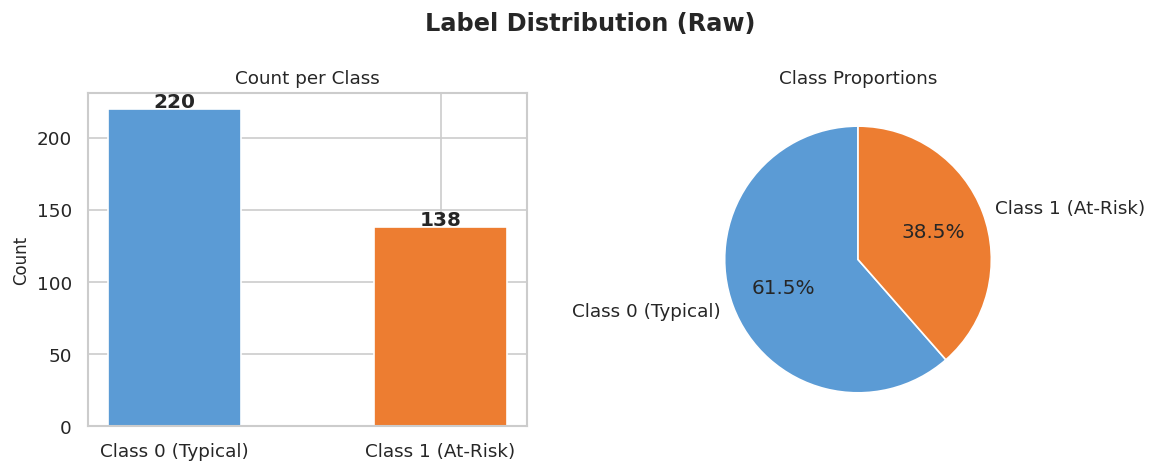

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fig.suptitle('Label Distribution (Raw)', fontweight='bold')

counts = df_raw['Label'].value_counts().sort_index()
labels = ['Class 0 (Typical)', 'Class 1 (At-Risk)']
colors = [TYPICAL_COLOR, AT_RIST_COLOR]

axes[0].bar(labels, counts.values, color=colors, edgecolor='white', width=0.5)
axes[0].set_ylabel('Count')
axes[0].set_title('Count per Class')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Class Proportions')

plt.tight_layout()
plt.show()

### 1.3 Feature Distribution

To analyze the underlying distribution of the independent variables, a grid of overlapping histograms overlaid with Kernel Density Estimate (KDE) curves is generated, stratified by class. A specific technical consideration in this visualization involves the handling of the `[-99]` sentinel values: they are purposefully retained in the histograms to visually represent the scope of missing data, but are dynamically excluded from the KDE calculations to prevent significant distortion of the probability density curves. This approach ensures an accurate visual assessment of feature separability, class overlap, and the presence of distribution outliers prior to formal dataset normalization.

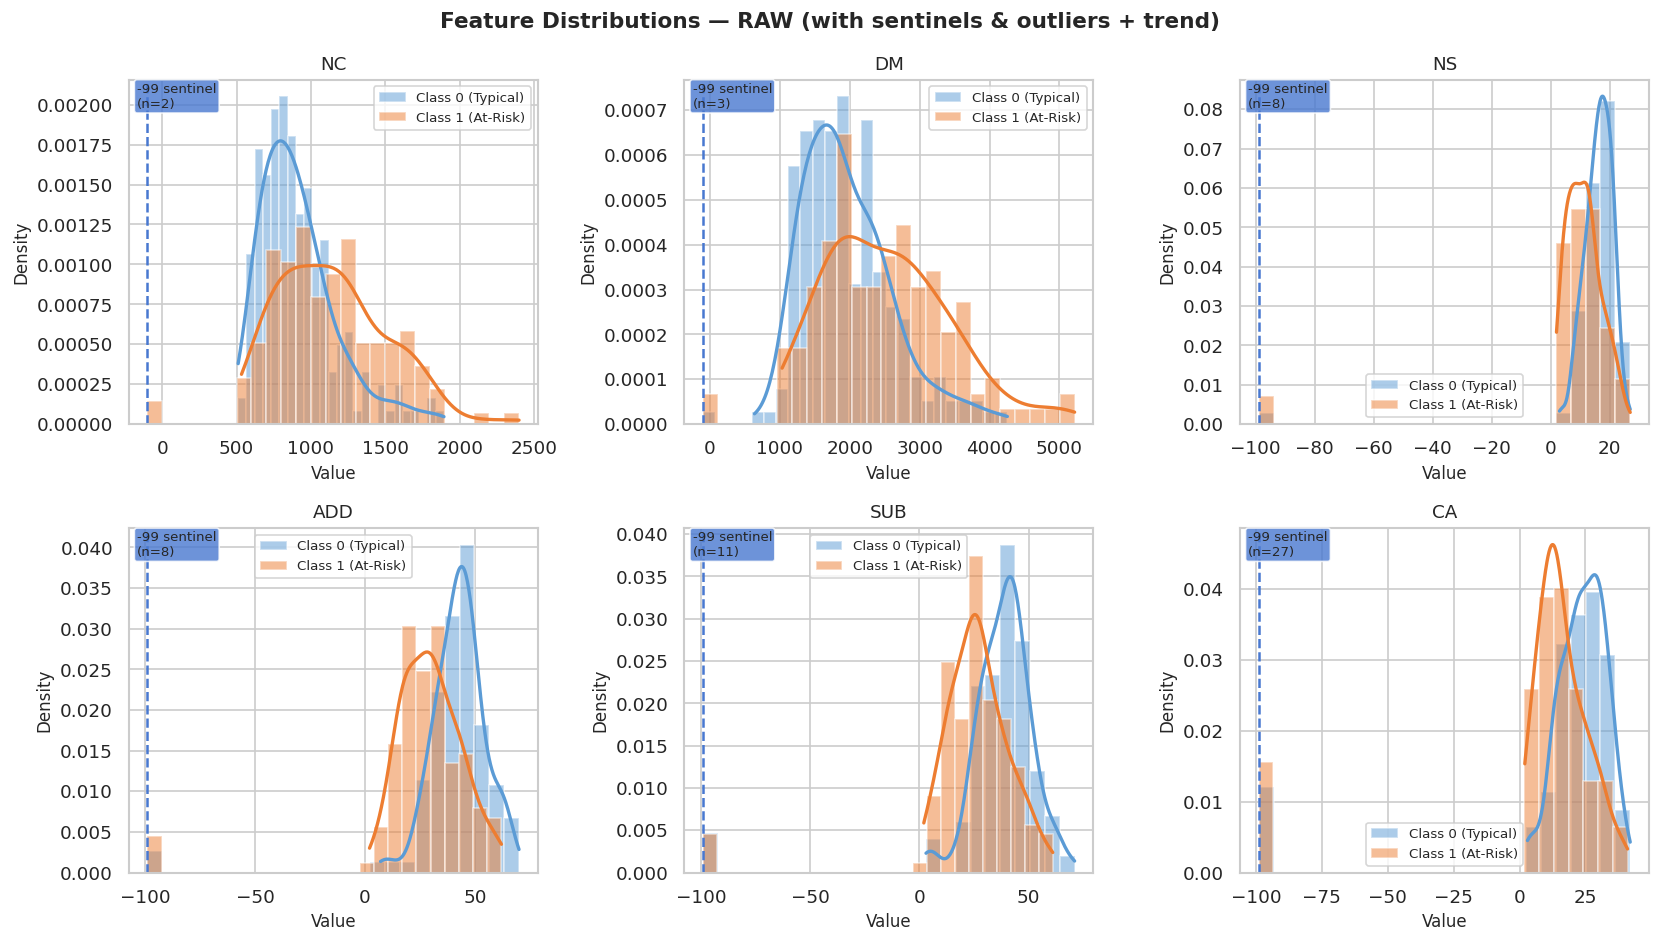

In [54]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions — RAW (with sentinels & outliers + trend)', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]

    for label, color in zip([0, 1], [TYPICAL_COLOR, AT_RIST_COLOR]):
        data = df_raw[df_raw['Label'] == label][col]

        # Histogram (keep sentinels visible)
        ax.hist(
            data, bins=25, alpha=0.5, color=color,
            label=f'Class {label} ({["Typical","At-Risk"][label]})',
            edgecolor='white', density=True
        )

        # ---- KDE trend (EXCLUDE sentinel values) ----
        # Use ~isin() to filter out all items in the list
        data_no_sentinel = data[~data.isin(DEFAULT_MISSING_VALUES)].dropna()

        if len(data_no_sentinel) > 1:
            kde = gaussian_kde(data_no_sentinel)
            x_vals = np.linspace(data_no_sentinel.min(), data_no_sentinel.max(), 200)
            y_vals = kde(x_vals)
            ax.plot(x_vals, y_vals, color=color, linewidth=2)

    # ---- Sentinel annotation + vertical line ----
    # Loop over the list of default missing values
    for idx, sentinel in enumerate(DEFAULT_MISSING_VALUES):
        n_sentinel = (df_raw[col] == sentinel).sum()
        
        if n_sentinel > 0:
            ax.axvline(sentinel, linestyle='--', linewidth=1.5)
            
            # Shift the text box down slightly if there are multiple sentinel types
            y_pos = 0.92 - (idx * 0.15)
            
            ax.annotate(
                f'{sentinel} sentinel\n(n={n_sentinel})',
                xy=(0.02, y_pos),
                xycoords='axes fraction',
                fontsize=8,
                bbox=dict(boxstyle='round,pad=0.2', alpha=0.8)
            )

    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')  
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 1.4 Feature x Class Outliers

This section utilizes boxplots to conduct a class-stratified analysis of feature dispersion and central tendencies. By partitioning the underlying data by the target label, we can visually assess the interquartile ranges (IQR) and reliably identify extreme outliers specific to each cohort. This stratified inspection is computationally crucial: because 'At-Risk' students intrinsically exhibit atypical scoring patterns, what might appear as a severe outlier on a global scale could actually represent a valid diagnostic signal within the minority class. Understanding these class-specific variances directly informs the localized, per-class IQR clipping strategy that will be implemented during the subsequent data cleaning phase.

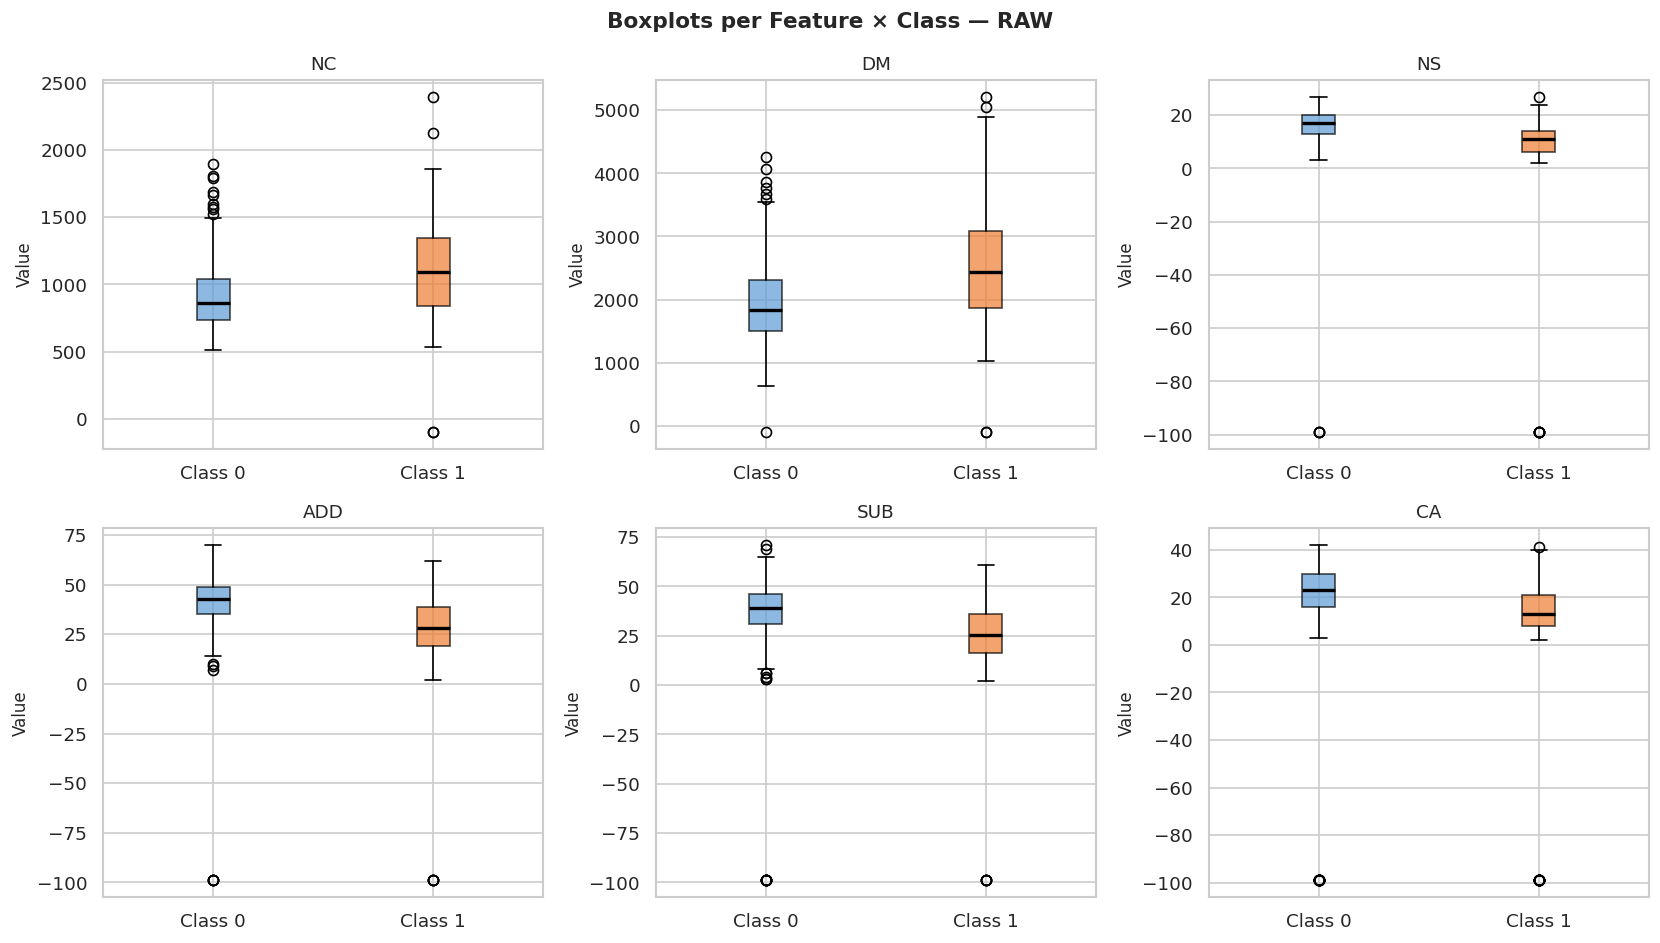

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots per Feature × Class — RAW', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]
    data_to_plot = [df_raw[df_raw['Label'] == lbl][col].dropna() for lbl in [0, 1]]
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [TYPICAL_COLOR, AT_RIST_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

### 1.5 Correlation Matrix

In this section, a pairwise Pearson correlation matrix is generated to quantify the collinearity and linear relationships among the independent features. To contextualize these interactions within the dataset's domain, the matrix is visually partitioned to highlight two validated theoretical constructs: Number Processing (`NC`, `DM`) and Arithmetic Fluency (`NS`, `ADD`, `SUB`, `CA`). 

A critical technical observation during this stage of the EDA is the presence of strong negative correlations crossing between these two feature groups. While computationally this might initially suggest a data inversion error or scaling anomaly, it is absolutely structurally sound. The Number Processing variables act as efficiency indices (reaction time divided by accuracy, meaning a higher score indicates worse performance), whereas the Arithmetic Fluency variables are raw correct counts (where a higher score indicates better performance). Explicitly mapping and verifying this expected inverse relationship serves as a crucial sanity check, confirming the structural integrity of our diagnostic metrics before applying any predictive algorithms.

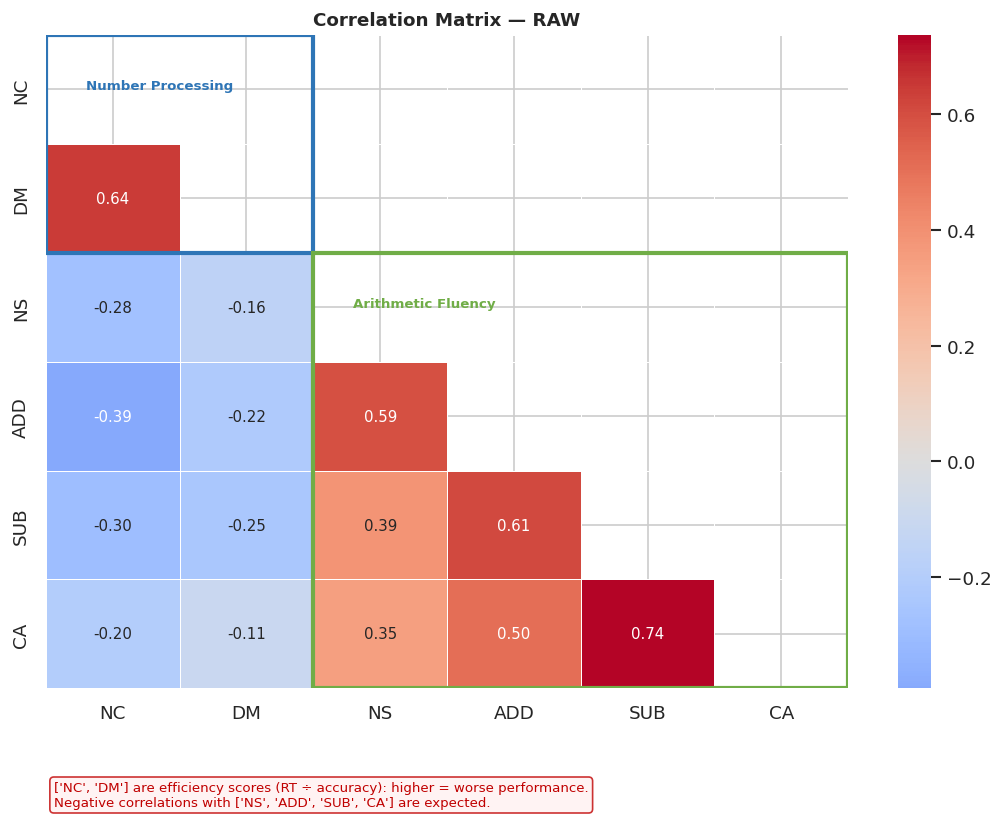

In [56]:
# Two-factor grouping
NUMBER_PROCESSING = ['NC', 'DM']
ARITHMETIC_FLUENCY = ['NS', 'ADD', 'SUB', 'CA']

# Correlation
corr_raw = df_raw[FEATURE_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_raw, dtype=bool))

sns.heatmap(corr_raw, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix — RAW', fontweight='bold')

# --- Dynamic mapping ---
col_index = {col: i for i, col in enumerate(corr_raw.columns)}

# Number Processing
np_idx = [col_index[c] for c in NUMBER_PROCESSING if c in col_index]
if np_idx:
    np_min, np_max = min(np_idx), max(np_idx)
    ax.add_patch(plt.Rectangle(
        (np_min, np_min),
        np_max - np_min + 1,
        np_max - np_min + 1,
        fill=False,
        edgecolor='#2E75B6',
        lw=2.5
    ))
    ax.text(np_min + 0.3, np_min + 0.5, 'Number Processing',
            fontsize=8, color='#2E75B6', fontweight='bold')

# Arithmetic Fluency
af_idx = [col_index[c] for c in ARITHMETIC_FLUENCY if c in col_index]
if af_idx:
    af_min, af_max = min(af_idx), max(af_idx)
    ax.add_patch(plt.Rectangle(
        (af_min, af_min),
        af_max - af_min + 1,
        af_max - af_min + 1,
        fill=False,
        edgecolor='#70AD47',
        lw=2.5
    ))
    ax.text(af_min + 0.3, af_min + 0.5, 'Arithmetic Fluency',
            fontsize=8, color='#70AD47', fontweight='bold')

# --- Stable annotation ---
ax.text(
    0.01, -0.18,
    f'{NUMBER_PROCESSING} are efficiency scores (RT ÷ accuracy): higher = worse performance.\n'
    f'Negative correlations with {ARITHMETIC_FLUENCY} are expected.',
    transform=ax.transAxes,
    fontsize=8,
    color='#C00000',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#C00000', alpha=0.8)
)

plt.tight_layout()
plt.show()

### 1.6 Pairplot

To further investigate the multidimensional feature space prior to dataset normalization, this cell generates a pairwise scatter plot matrix overlaid with class-specific color mappings. This visualization provides a comprehensive view of both univariate distributions—via Kernel Density Estimates on the principal diagonal—and bivariate relationships across all independent variables. 

The variables are intentionally ordered to group the Number Processing metrics (`NC`, `DM`) alongside the Arithmetic Fluency metrics (`NS`, `ADD`, `SUB`, `CA`). By organizing the grid according to this theoretical two-factor structure, we can visually validate the clustering behaviors and inverse scaling relationships identified in the correlation matrix. From a machine learning perspective, examining these 2D projections is highly valuable; it helps identify localized regions of class separability, multivariate outliers, and non-linear feature interactions that decision tree algorithms, such as C4.5, are specifically optimized to exploit.

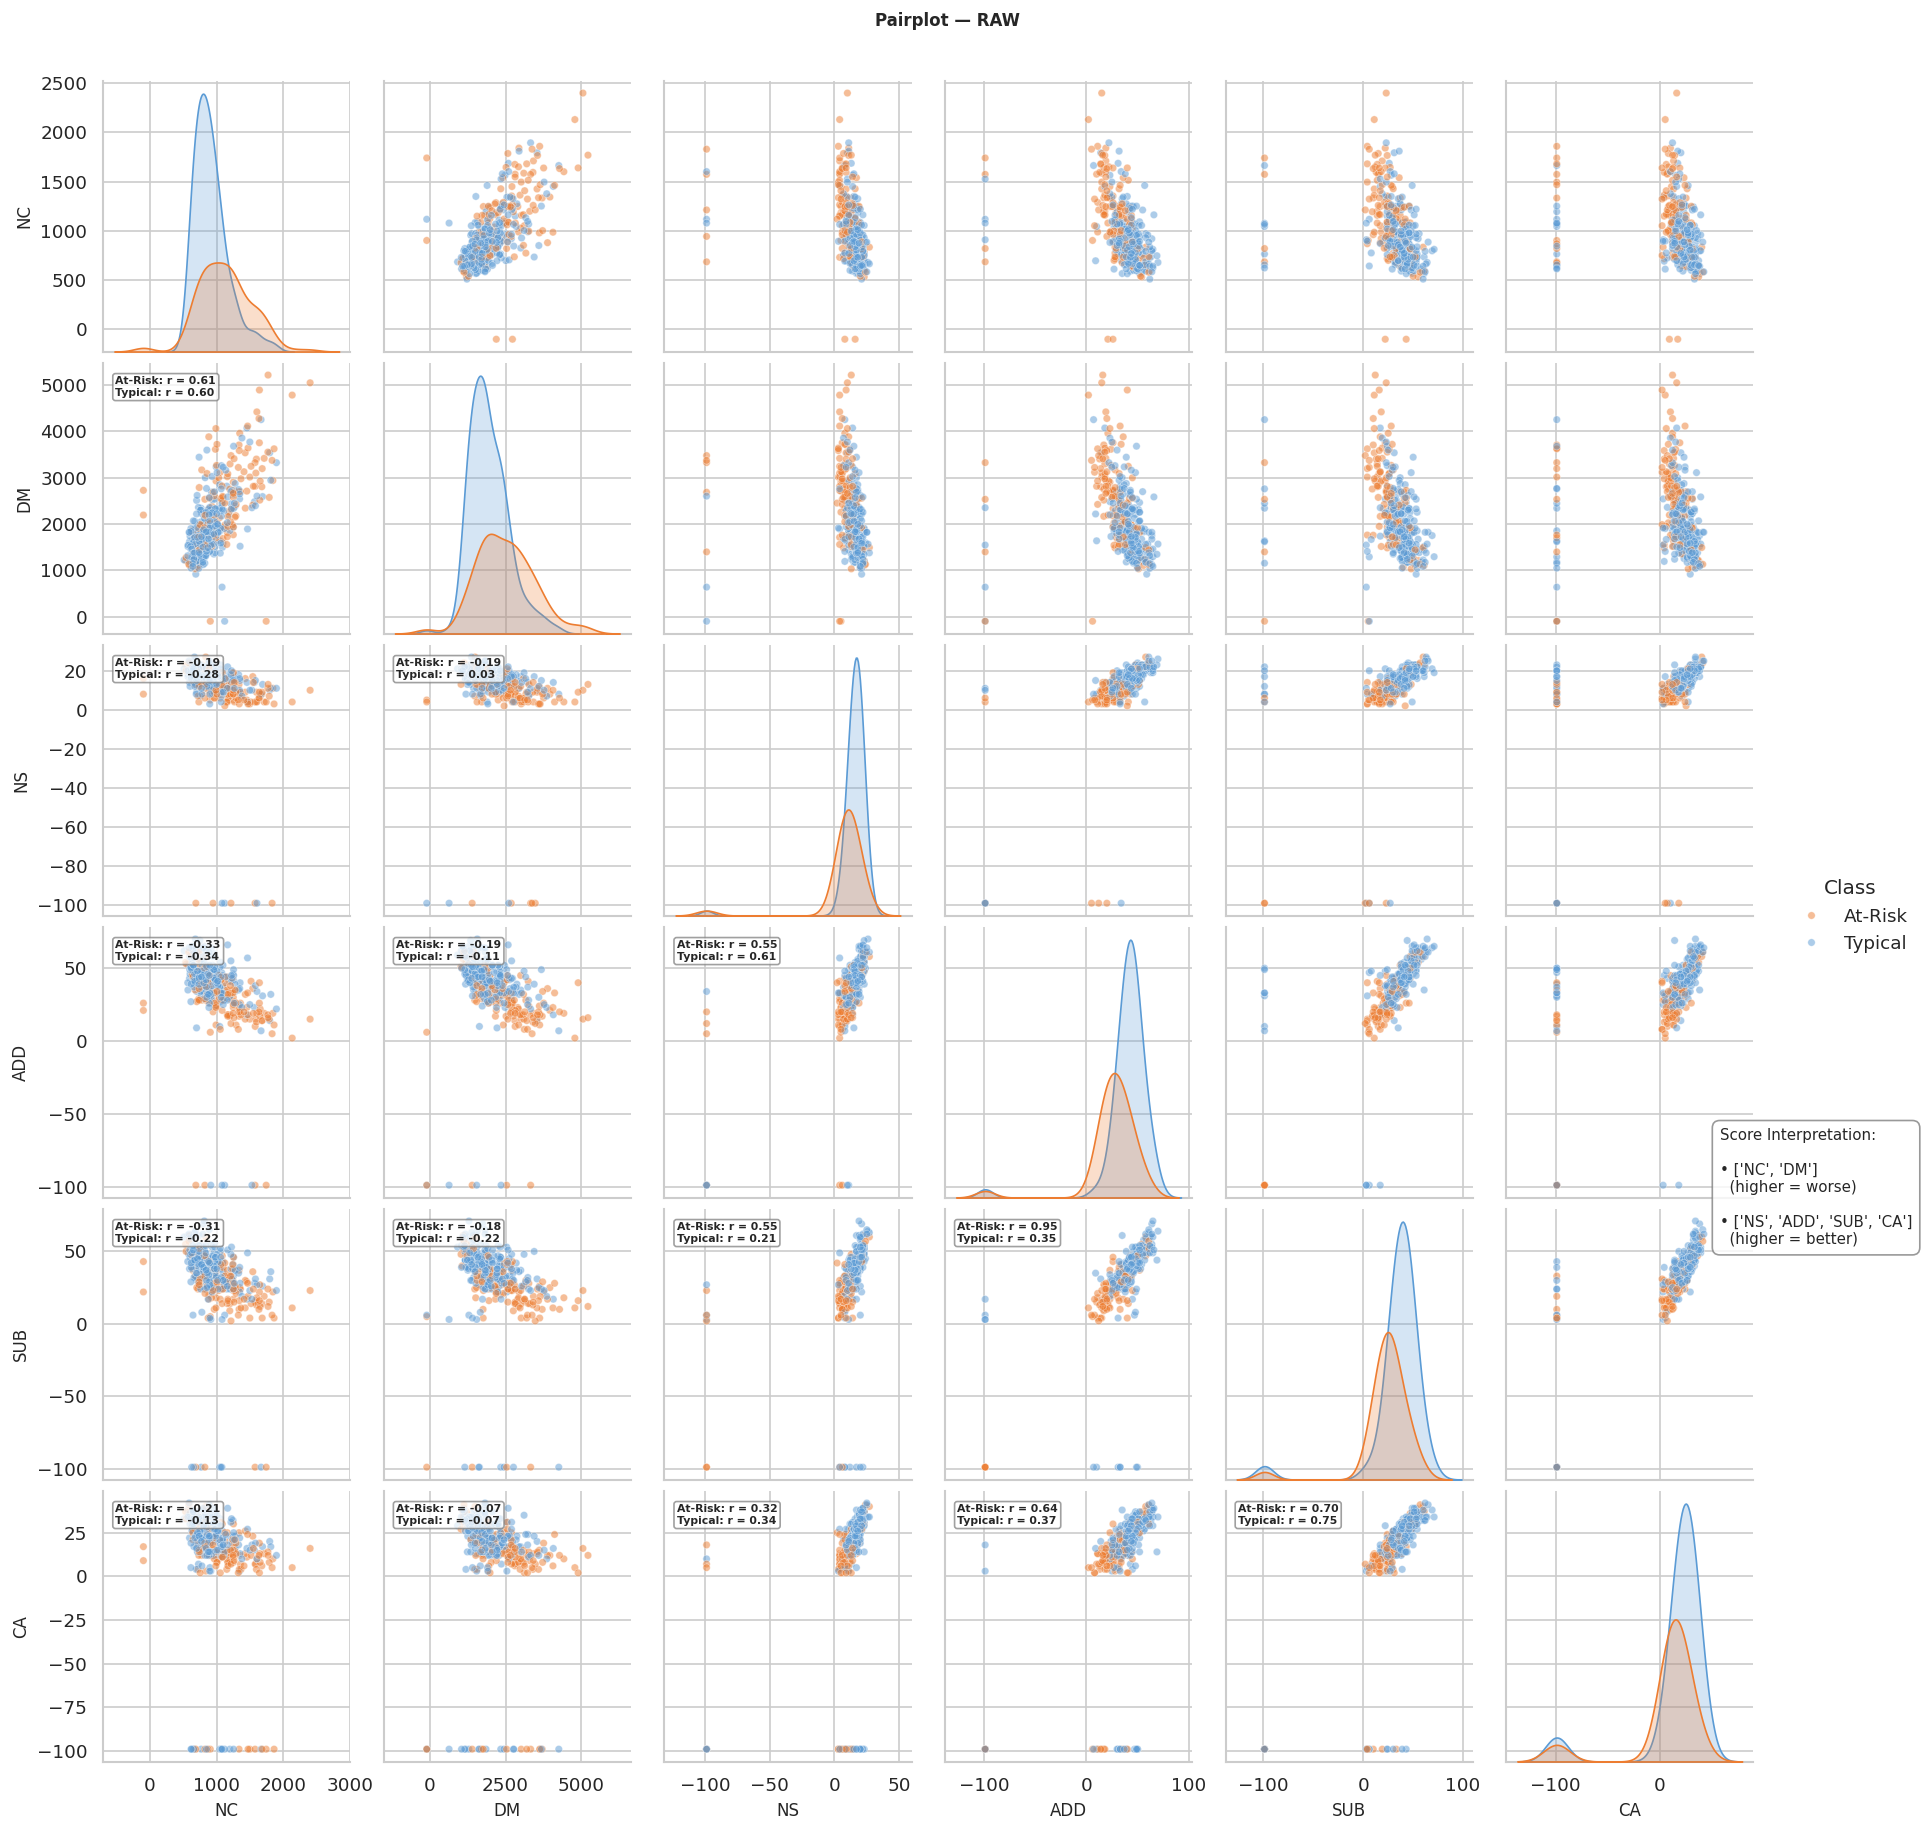

In [57]:
pair_df = df_raw.copy()
pair_df["Class"] = pair_df["Label"].map({
    0: "Typical",
    1: "At-Risk"
})

FEATURES = [*NUMBER_PROCESSING, *ARITHMETIC_FLUENCY]

g = sns.pairplot(
    pair_df,
    vars=FEATURES,
    hue="Class",
    palette={
        "Typical": TYPICAL_COLOR,
        "At-Risk": AT_RIST_COLOR
    },
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20}
)

# Add class-specific Pearson r values
add_class_specific_corr(
    g=g,
    df=pair_df,
    features=FEATURES,
    class_col="Class"
)

g.figure.suptitle(
    "Pairplot — RAW",
    y=1.02,
    fontweight="bold",
    fontsize=10
)

g.figure.text(
    0.9, 0.4,
    f"Score Interpretation:\n\n• {NUMBER_PROCESSING}\n  (higher = worse)\n\n• {ARITHMETIC_FLUENCY}\n  (higher = better)",
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.8
    )
)

plt.show()

## 2. Cleanup Dataset

### 2.1 Replace known invalid sentinels

In [58]:
df = df_raw.copy()
df = df.replace(DEFAULT_MISSING_VALUES, np.nan)
print(f"Cells with values {DEFAULT_MISSING_VALUES} are replaced with nan")

Cells with values [-99] are replaced with nan


### 2.2 Ensure numeric safety
Since this dataset are score results, there should be no negative values.

In [59]:
for col in df.columns:
    if col == 'Label':
        continue
    df.loc[df[col] < 0, col] = np.nan

print('NaN counts after sentinel/negative removal:')
print(df[FEATURE_COLUMNS].isna().sum())

NaN counts after sentinel/negative removal:
NC      2
DM      3
NS      8
ADD     8
SUB    11
CA     27
dtype: int64


#### 2.2.1 Analyse Missingness by Class
Since missing values represent absent/incomplete students (not random), we first check whether missingness is disproportionate in the At-Risk class. If so, it is itself a diagnostic signal and must be preserved as indicator flags before imputing.

In [60]:
print("=== Missing counts per feature per class ===")
missing_by_class = df.groupby('Label')[FEATURE_COLUMNS].apply(lambda x: x.isna().sum())

# Display-friendly copy
missing_by_class_display = missing_by_class.copy()
missing_by_class_display.index = ['Typical (0)', 'At-Risk (1)']
print(missing_by_class_display)

print("\n=== Missing rate (%) per feature per class ===")
missing_rate = df.groupby('Label')[FEATURE_COLUMNS].apply(
    lambda x: (x.isna().sum() / len(x) * 100).round(1)
)

# Display-friendly copy
missing_rate_display = missing_rate.copy()
missing_rate_display.index = ['Typical (0)', 'At-Risk (1)']
print(missing_rate_display)

# ---- Keep ORIGINAL numeric index for conversion ----
missing_rate_decimal = (missing_rate / 100).round(3)


# Safe conversion to nested dict
MISSING_RATES = {
    int(label): {
        k: float(v) for k, v in row.items() if pd.notna(v)
    }
    for label, row in missing_rate_decimal.iterrows()
}

print("\nSaving missing rates...")
with open(OUTPUTS_DIR / "missing_rates.json", "w") as f:
    json.dump(MISSING_RATES, f, indent=4)

print("Done Saving.")

=== Missing counts per feature per class ===
             NC  DM  NS  ADD  SUB  CA
Typical (0)   0   1   3    4    7  15
At-Risk (1)   2   2   5    4    4  12

=== Missing rate (%) per feature per class ===
              NC   DM   NS  ADD  SUB   CA
Typical (0)  0.0  0.5  1.4  1.8  3.2  6.8
At-Risk (1)  1.4  1.4  3.6  2.9  2.9  8.7

Saving missing rates...
Done Saving.


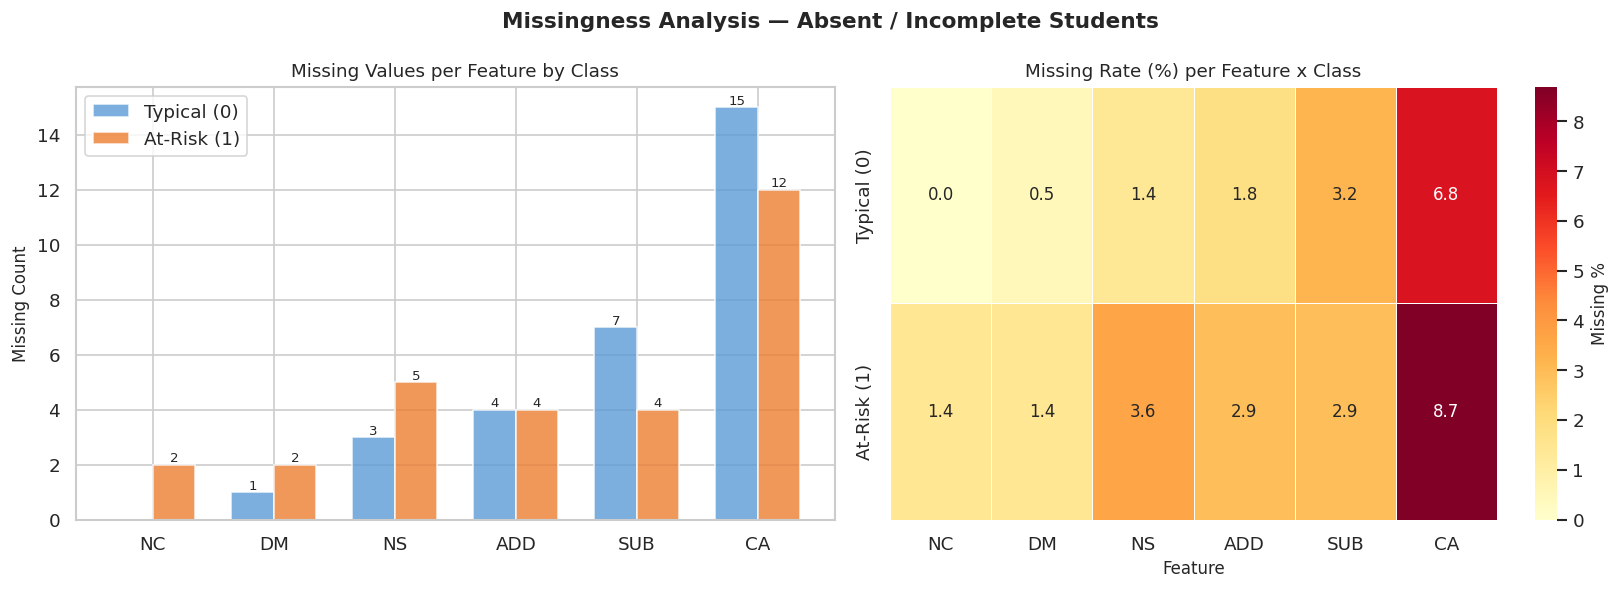


59 missing values found. Proceeding to create indicator flags.


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Missingness Analysis — Absent / Incomplete Students', fontweight='bold', fontsize=13)

# Chart 1: Missing count per feature, grouped by class
ax = axes[0]
miss_c0 = df[df['Label'] == 0][FEATURE_COLUMNS].isna().sum()
miss_c1 = df[df['Label'] == 1][FEATURE_COLUMNS].isna().sum()
x = np.arange(len(FEATURE_COLUMNS))
width = 0.35
ax.bar(x - width/2, miss_c0, width, label='Typical (0)', color=TYPICAL_COLOR, alpha=0.8)
ax.bar(x + width/2, miss_c1, width, label='At-Risk (1)',     color=AT_RIST_COLOR, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_COLUMNS)
ax.set_ylabel('Missing Count')
ax.set_title('Missing Values per Feature by Class')
ax.legend()
for xi, (v0, v1) in enumerate(zip(miss_c0, miss_c1)):
    if v0 > 0: ax.text(xi - width/2, v0 + 0.1, str(v0), ha='center', fontsize=8)
    if v1 > 0: ax.text(xi + width/2, v1 + 0.1, str(v1), ha='center', fontsize=8)

# Chart 2: Missing rate heatmap
ax2 = axes[1]
rate_data = pd.DataFrame({
    'Typical (0)': (df[df['Label']==0][FEATURE_COLUMNS].isna().sum() / (df['Label']==0).sum() * 100),
    'At-Risk (1)':     (df[df['Label']==1][FEATURE_COLUMNS].isna().sum() / (df['Label']==1).sum() * 100)
}).T
sns.heatmap(rate_data, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax2,
            linewidths=0.5, cbar_kws={'label': 'Missing %'}, annot_kws={'size': 10})
ax2.set_title('Missing Rate (%) per Feature x Class')
ax2.set_xlabel('Feature')

plt.tight_layout()
plt.show()

total_miss = df[FEATURE_COLUMNS].isna().sum().sum()
if total_miss == 0:
    print("\nNo missing values found — missingness flags will be all-zero.")
else:
    print(f"\n{total_miss} missing values found. Proceeding to create indicator flags.")

#### 2.2.2 Create Missingness Indicator Flags
For each feature with any missing values, we add a binary `{feature}_incomplete` flag (1 = absent/did not finish, 0 = completed). These flags preserve the absence signal before it is overwritten by imputation.

In [62]:
if total_miss > 0:
    flag_cols = []
    for col in FEATURE_COLUMNS:
        missing_mask = df[col].isna()
        if missing_mask.sum() > 0:
            flag_name = f'{col}_incomplete'
            df[flag_name] = missing_mask.astype(int)
            flag_cols.append(flag_name)
            print(f'  Created: {flag_name}  ({missing_mask.sum()} students flagged)')

    # Calculate students with any missing features dynamically
    any_missing_mask = df[FEATURE_COLUMNS].isna().any(axis=1)

    print(f'\nStudents with any incompleteness: {any_missing_mask.sum()}')
    print(f'  Typical: {any_missing_mask[df["Label"]==0].sum()}')
    print(f'  At-Risk:     {any_missing_mask[df["Label"]==1].sum()}')
    print(f'\nFlag columns added: {flag_cols}')

  Created: NC_incomplete  (2 students flagged)
  Created: DM_incomplete  (3 students flagged)
  Created: NS_incomplete  (8 students flagged)
  Created: ADD_incomplete  (8 students flagged)
  Created: SUB_incomplete  (11 students flagged)
  Created: CA_incomplete  (27 students flagged)

Students with any incompleteness: 35
  Typical: 18
  At-Risk:     17

Flag columns added: ['NC_incomplete', 'DM_incomplete', 'NS_incomplete', 'ADD_incomplete', 'SUB_incomplete', 'CA_incomplete']


#### 2.2.3 Count the missingness indicator flags per label

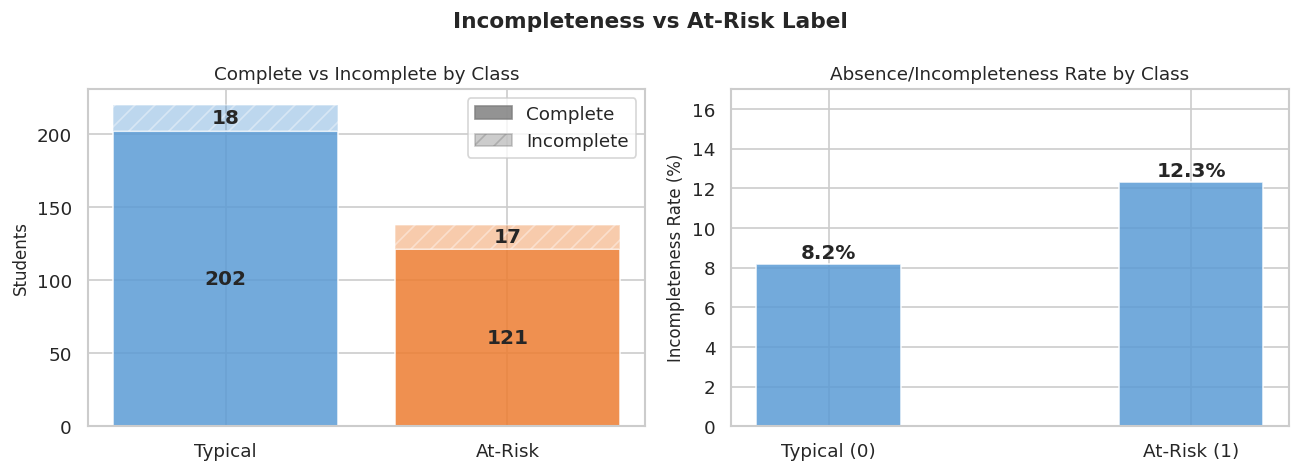

In [63]:
if any_missing_mask.sum() > 0:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle('Incompleteness vs At-Risk Label', fontweight='bold', fontsize=13)

    # Stacked bar: incomplete vs complete per class
    ax = axes[0]
    for lbl, color, name in [(0,TYPICAL_COLOR,'Typical'),(1,AT_RIST_COLOR,'At-Risk')]:
        class_mask = df['Label'] == lbl
        
        # Use our dynamically created mask instead of df['any_incomplete']
        n_inc  = any_missing_mask[class_mask].sum()
        n_comp = class_mask.sum() - n_inc
        
        ax.bar(name, n_comp, color=color, alpha=0.85)
        ax.bar(name, n_inc,  bottom=n_comp, color=color, alpha=0.4, hatch='//')
        
        # Label the complete count (centered in the bottom bar)
        if n_comp > 0:
            ax.text(name, n_comp / 2, str(n_comp), ha='center', va='center', fontweight='bold')
            
        # Label the incomplete count (centered in the top hatched bar)
        if n_inc > 0:
            ax.text(name, n_comp + (n_inc / 2), str(n_inc), ha='center', va='center', fontweight='bold')
        
    ax.set_ylabel('Students')
    ax.set_title('Complete vs Incomplete by Class')
    handles = [
        plt.Rectangle((0,0),1,1, color='grey', alpha=0.85, label='Complete'),
        plt.Rectangle((0,0),1,1, color='grey', alpha=0.4, hatch='//', label='Incomplete')
    ]
    ax.legend(handles=handles)

    # Incompleteness rate per class
    ax2 = axes[1]
    rates = [
        any_missing_mask[df['Label']==0].mean() * 100,
        any_missing_mask[df['Label']==1].mean() * 100
    ]
    bars = ax2.bar(['Typical (0)', 'At-Risk (1)'], rates,
                   color=[TYPICAL_COLOR,TYPICAL_COLOR], alpha=0.85, width=0.4)
    ax2.set_ylabel('Incompleteness Rate (%)')
    ax2.set_title('Absence/Incompleteness Rate by Class')
    ax2.set_ylim(0, max(rates)*1.3 + 1)
    for bar, rate in zip(bars, rates):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{rate:.1f}%', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()
else:
    print('No missing values in dataset — incompleteness chart skipped.')

### 2.3 Impute NaNs with Per-Class Median 

With the informative absence signals successfully preserved as binary flags, the raw dataset must now be numerically complete before subsequent modeling stages can proceed. Imputation is performed using the median rather than the mean to ensure robustness against the severe outliers identified during the univariate analysis. Crucially, this imputation is executed dynamically on a **per-class basis** (group-aware). 

Since 'At-Risk' students intrinsically exhibit fundamentally different scoring distributions and central tendencies compared to their 'Typical' peers, applying a global dataset median would artifactually force missing 'At-Risk' data points toward the typical baseline, destroying the diagnostic signal. By stratifying the imputation by the target label, we ensure that the imputed values accurately reflect the localized statistical reality of the student's respective cohort. In-Group. If an entire feature column for a specific class happens to be missing (NaN), a global fallback median is applied to prevent execution errors.

In [64]:
df[FEATURE_COLUMNS] = df.groupby('Label')[FEATURE_COLUMNS].transform(
    lambda x: x.fillna(x.median())
)
# Fallback: global median if an entire class column is NaN
df = df.fillna(df.median(numeric_only=True))

### 2.4 Per-Class IQR Clipping
Clipping is done within each class separately. At-Risk students may have genuinely different score ranges — clipping globally would corrupt that signal.

In [65]:
clip_bounds = {}
for col in FEATURE_COLUMNS:
    clip_bounds[col] = {}
    for label in df['Label'].unique():
        mask = df['Label'] == label
        Q1 = df.loc[mask, col].quantile(0.25)
        Q3 = df.loc[mask, col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        clip_bounds[col][label] = (lower, upper)
        df.loc[mask, col] = df.loc[mask, col].clip(lower, upper)

df = df.reset_index(drop=True)      # Sanity Check

print('Per-class clipping bounds applied:')
for col, bounds in clip_bounds.items():
    for label, (lo, hi) in bounds.items():
        name = 'Typical' if label == 0 else 'At-Risk'
        print(f'  {col} [{name}]: [{lo:.2f}, {hi:.2f}]')

Per-class clipping bounds applied:
  NC [At-Risk]: [162.37, 2050.36]
  NC [Typical]: [271.50, 1503.74]
  DM [At-Risk]: [68.71, 4902.44]
  DM [Typical]: [271.80, 3541.94]
  NS [At-Risk]: [-3.50, 24.50]
  NS [Typical]: [2.50, 30.50]
  ADD [At-Risk]: [-10.00, 68.00]
  ADD [Typical]: [16.50, 68.50]
  SUB [At-Risk]: [-11.50, 64.50]
  SUB [Typical]: [8.50, 68.50]
  CA [At-Risk]: [-5.88, 37.12]
  CA [Typical]: [1.88, 46.88]


## 3. Exploratory Data Analysis — After Cleaning

### 3.1 Cleaned Dataset View

In [66]:
df_clean = df.copy()

print("=== Dataset Info ===")
print(df_clean.info())

print("\n=== Dataset Head ===")
print(df_clean.head())

print("\n=== Summary Statistics (raw) ===")
print(df_clean.describe().T.round(2))

print("\n=== Missing / Sentinel Values ===")
sentinel_mask = df_clean.isin(DEFAULT_MISSING_VALUES)
print(f"Cells equal to {DEFAULT_MISSING_VALUES}:", sentinel_mask.sum().sum())
print(sentinel_mask.sum()[sentinel_mask.sum() > 0])

print("\n=== Label Distribution ===")
print(df_clean['Label'].value_counts())

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 358 entries, 0 to 357
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   NC              358 non-null    float64
 1   DM              358 non-null    float64
 2   NS              358 non-null    float64
 3   ADD             358 non-null    float64
 4   SUB             358 non-null    float64
 5   CA              358 non-null    float64
 6   Label           358 non-null    int64  
 7   NC_incomplete   358 non-null    int64  
 8   DM_incomplete   358 non-null    int64  
 9   NS_incomplete   358 non-null    int64  
 10  ADD_incomplete  358 non-null    int64  
 11  SUB_incomplete  358 non-null    int64  
 12  CA_incomplete   358 non-null    int64  
dtypes: float64(6), int64(7)
memory usage: 36.5 KB
None

=== Dataset Head ===
            NC           DM    NS   ADD   SUB    CA  Label  NC_incomplete  \
0  1248.000000  2903.384615   5.0  23.0  17.

### 3.2 Feature Distribution

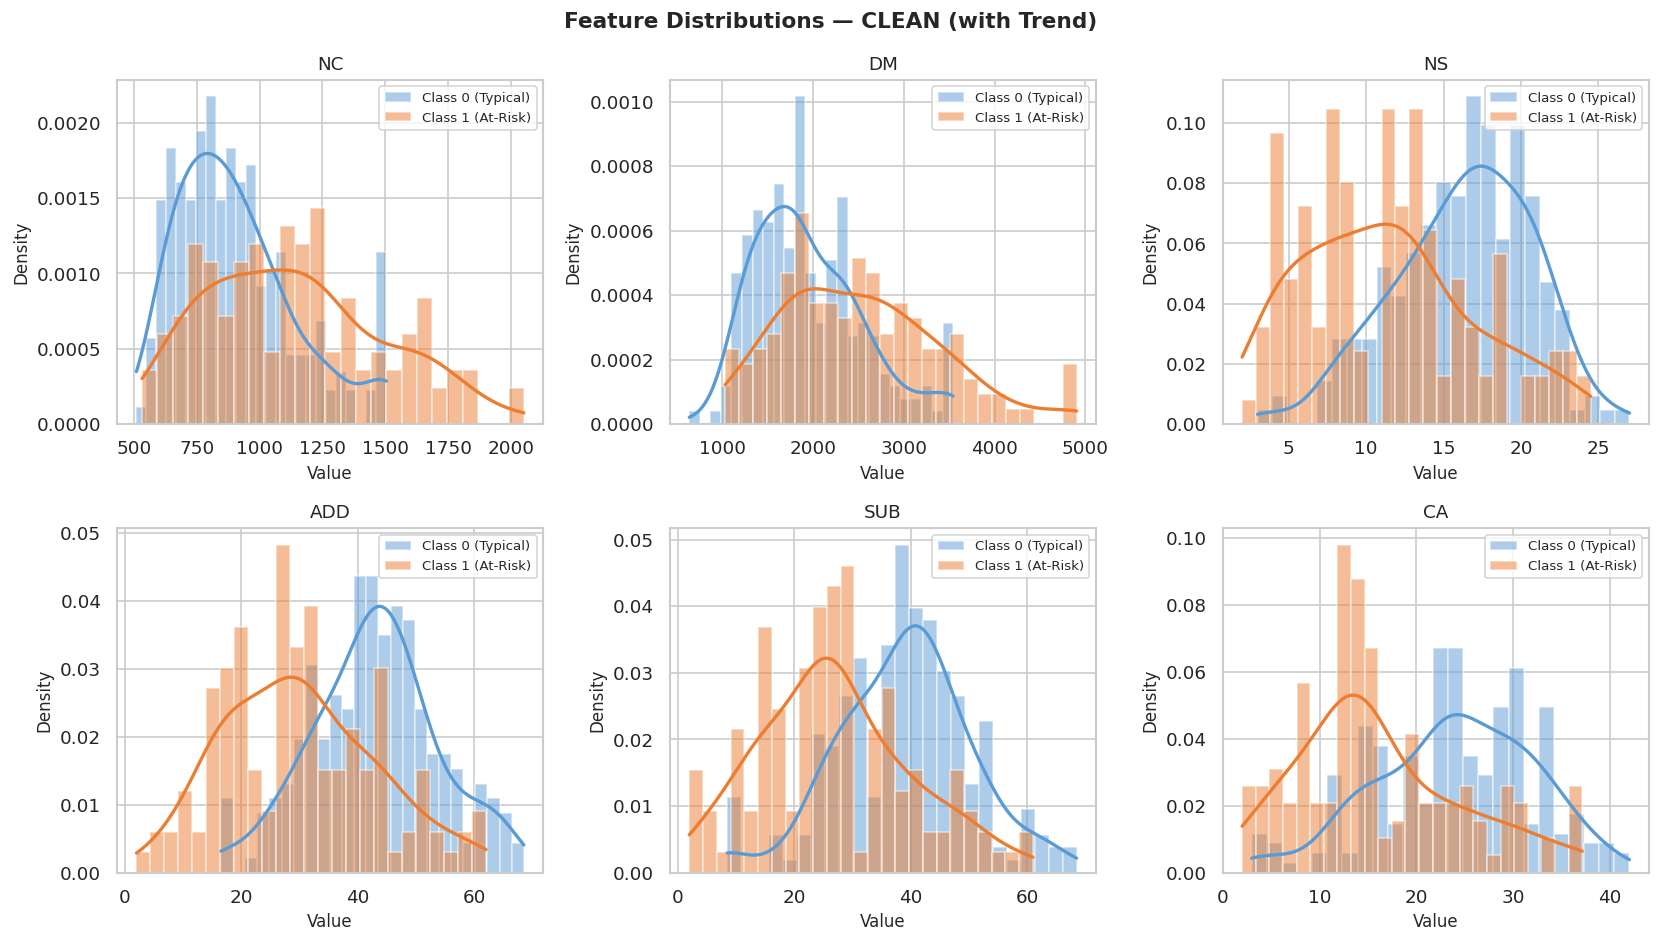

In [67]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Feature Distributions — CLEAN (with Trend)', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]

    for label, color in zip([0, 1], [TYPICAL_COLOR, AT_RIST_COLOR]):
        data = df_clean[df_clean['Label'] == label][col].dropna()

        ax.hist(
            data, bins=25, alpha=0.5, color=color,
            label=f'Class {label} ({["Typical","At-Risk"][label]})',
            edgecolor='white', density=True  # <-- important for overlay
        )

        if len(data) > 1:
            from scipy.stats import gaussian_kde

            kde = gaussian_kde(data)
            x_vals = np.linspace(data.min(), data.max(), 200)
            y_vals = kde(x_vals)

            ax.plot(x_vals, y_vals, color=color, linewidth=2)

    ax.set_title(col)
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')  # changed from Frequency
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 3.3 Feature x Class Outliers

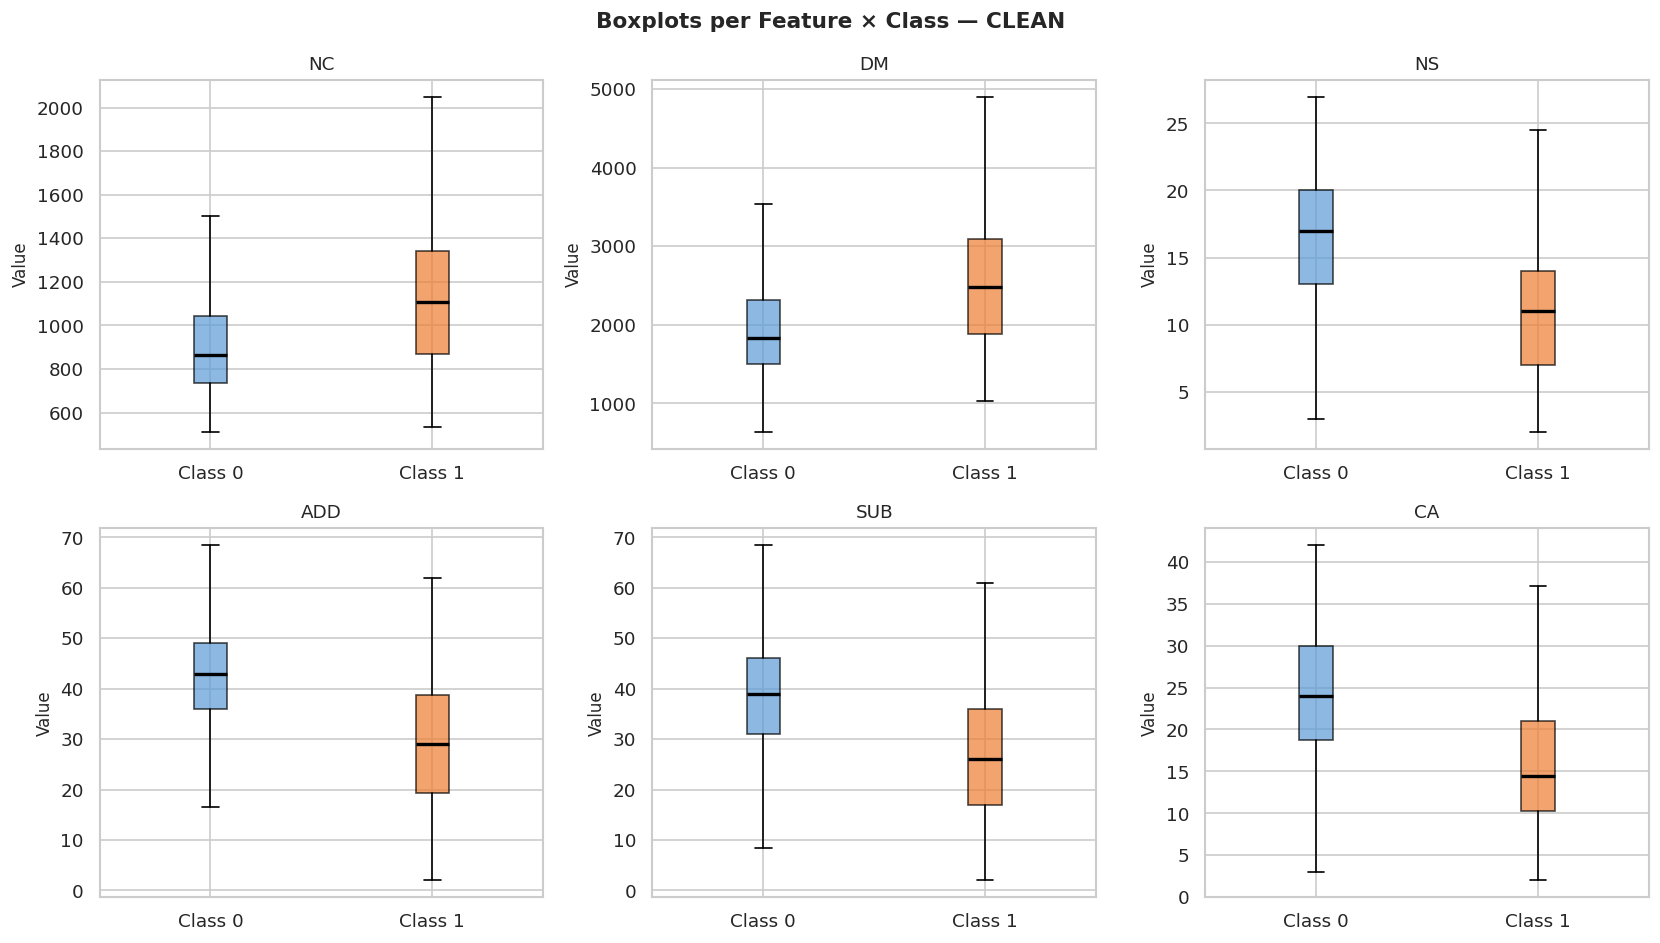

In [68]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Boxplots per Feature × Class — CLEAN', fontweight='bold', fontsize=13)
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLUMNS):
    ax = axes[i]
    data_to_plot = [df_clean[df_clean['Label'] == lbl][col] for lbl in [0, 1]]
    bp = ax.boxplot(data_to_plot, patch_artist=True, notch=False,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], [TYPICAL_COLOR, AT_RIST_COLOR]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['Class 0', 'Class 1'])
    ax.set_title(col)
    ax.set_ylabel('Value')

plt.tight_layout()
plt.show()

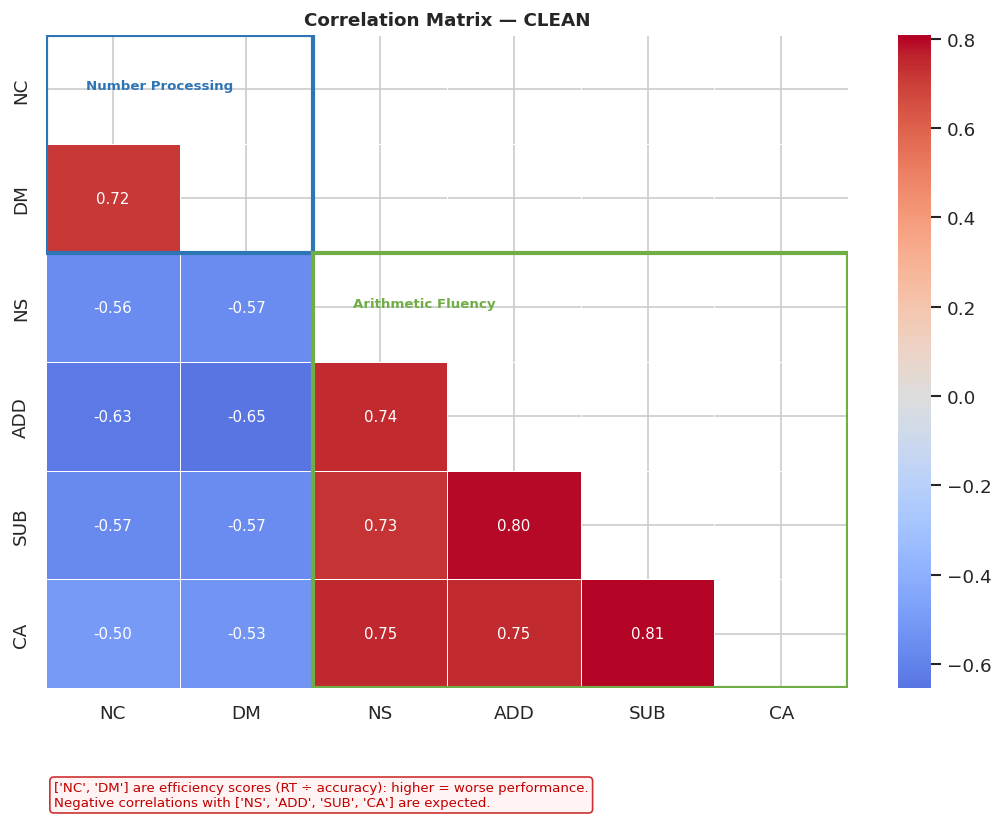

In [69]:
# Correlation
corr_clean = df_clean[[*NUMBER_PROCESSING, *ARITHMETIC_FLUENCY]].corr()

fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_clean, dtype=bool))

sns.heatmap(corr_clean, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
    center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})

ax.set_title('Correlation Matrix — CLEAN', fontweight='bold')

# --- Dynamic mapping ---
col_index = {col: i for i, col in enumerate(corr_clean.columns)}

# Number Processing
np_idx = [col_index[c] for c in NUMBER_PROCESSING if c in col_index]
if np_idx:
    np_min, np_max = min(np_idx), max(np_idx)
    ax.add_patch(plt.Rectangle(
        (np_min, np_min),
        np_max - np_min + 1,
        np_max - np_min + 1,
        fill=False,
        edgecolor='#2E75B6',
        lw=2.5
    ))
    ax.text(np_min + 0.3, np_min + 0.5, 'Number Processing',
            fontsize=8, color='#2E75B6', fontweight='bold')

# Arithmetic Fluency
af_idx = [col_index[c] for c in ARITHMETIC_FLUENCY if c in col_index]
if af_idx:
    af_min, af_max = min(af_idx), max(af_idx)
    ax.add_patch(plt.Rectangle(
        (af_min, af_min),
        af_max - af_min + 1,
        af_max - af_min + 1,
        fill=False,
        edgecolor='#70AD47',
        lw=2.5
    ))
    ax.text(af_min + 0.3, af_min + 0.5, 'Arithmetic Fluency',
            fontsize=8, color='#70AD47', fontweight='bold')

# --- Stable annotation ---
ax.text(
    0.01, -0.18,
    f'{NUMBER_PROCESSING} are efficiency scores (RT ÷ accuracy): higher = worse performance.\n'
    f'Negative correlations with {ARITHMETIC_FLUENCY} are expected.',
    transform=ax.transAxes,
    fontsize=8,
    color='#C00000',
    bbox=dict(boxstyle='round,pad=0.3', fc='#fff0f0', ec='#C00000', alpha=0.8)
)

plt.tight_layout()
plt.show()

### 3.4 Pairplot 

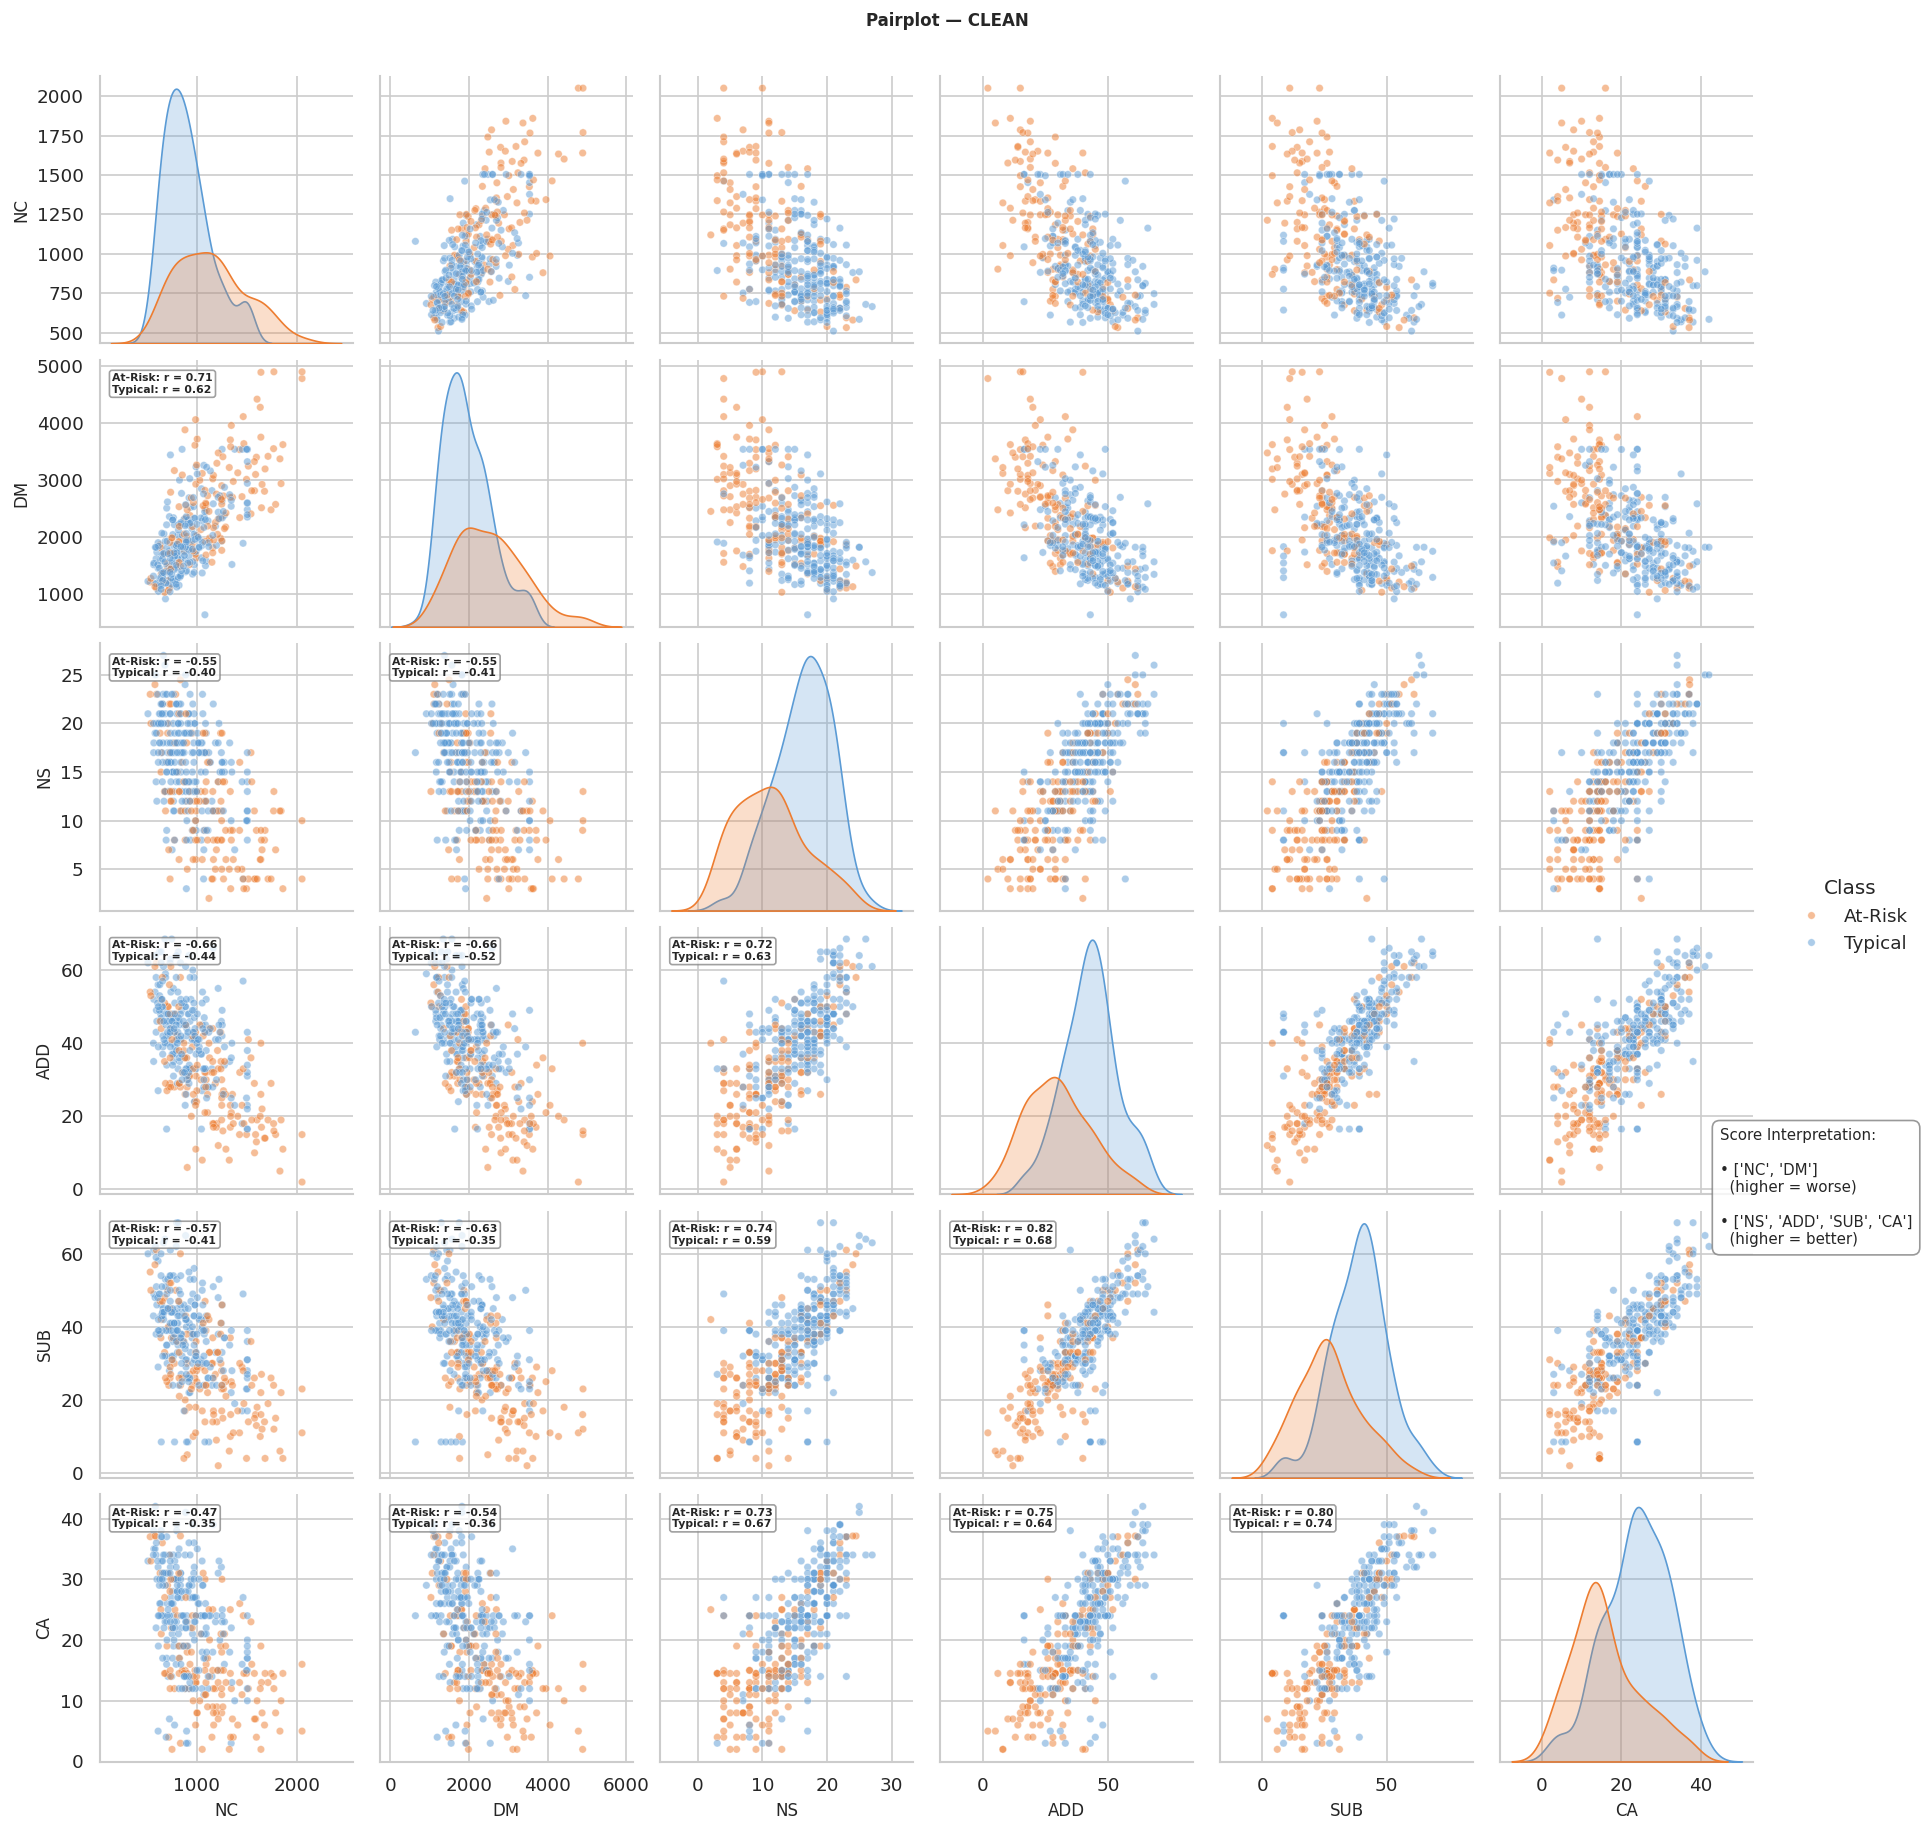

In [70]:
pair_df_c = df_clean.copy()
pair_df_c["Class"] = pair_df_c["Label"].map({
    0: "Typical",
    1: "At-Risk"
})

FEATURES = [*NUMBER_PROCESSING, *ARITHMETIC_FLUENCY]

g = sns.pairplot(
    pair_df_c,
    vars=FEATURES,
    hue="Class",
    palette={
        "Typical": TYPICAL_COLOR,
        "At-Risk": AT_RIST_COLOR
    },
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 20}
)

# Add class-specific Pearson r values
add_class_specific_corr(
    g=g,
    df=pair_df_c,
    features=FEATURES,
    class_col="Class"
)

g.figure.suptitle(
    "Pairplot — CLEAN",
    y=1.02,
    fontweight="bold",
    fontsize=10
)

g.figure.text(
    0.9, 0.4,
    f"Score Interpretation:\n\n• {NUMBER_PROCESSING}\n  (higher = worse)\n\n• {ARITHMETIC_FLUENCY}\n  (higher = better)",
    ha="left",
    va="top",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.5",
        facecolor="white",
        edgecolor="gray",
        alpha=0.8
    )
)

plt.show()

## 4. Before vs After Comparison

### 4.1 Numeric Comparison

In [71]:
# Numeric comparison table: mean, std, min, max for each feature
rows = []
for col in FEATURE_COLUMNS:
    for label, dataset in [('RAW', df_raw), ('CLEAN', df_clean)]:
        s = dataset[col]
        rows.append({
            'Feature': col, 'Dataset': label,
            'Mean': s.mean(), 'Std': s.std(),
            'Min': s.min(), 'Max': s.max(),
            'NaN': s.isna().sum()
        })

comparison = pd.DataFrame(rows).set_index(['Feature', 'Dataset']).round(2)
print(comparison.to_string())

                    Mean     Std     Min      Max  NaN
Feature Dataset                                       
NC      RAW       993.86  329.90  -99.00  2399.14    0
        CLEAN     994.96  305.99  510.82  2050.36    0
DM      RAW      2158.84  813.41  -99.00  5217.22    0
        CLEAN    2171.81  770.70  637.50  4902.44    0
NS      RAW        11.88   17.64  -99.00    27.00    0
        CLEAN      14.38    5.44    2.00    27.00    0
ADD     RAW        34.87   24.30  -99.00    70.00    0
        CLEAN      37.96   13.30    2.00    68.50    0
SUB     RAW        30.18   26.66  -99.00    71.00    0
        CLEAN      34.32   13.34    2.00    68.50    0
CA      RAW        12.00   33.01  -99.00    42.00    0
        CLEAN      20.94    9.12    2.00    42.00    0


## 5. Save Cleaned Dataset

In [72]:
df_clean.to_csv(DATASETS_DIR / 'cleaned_dataset.csv', index=False)